In [1]:
import os
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# Set seed for full execution reproducibility
np.random.seed(17)

# Define storage folder structure
raw_dir = Path("data/raw")
processed_dir = Path("data/processed")
raw_dir.mkdir(parents=True, exist_ok=True)
processed_dir.mkdir(parents=True, exist_ok=True)

# Generate business day sequence
dates = pd.date_range(start="2022-01-03", end="2022-06-10", freq="B")

# Generate baseline return series ~ N(0, 0.01)
returns = np.random.normal(0, 0.01, size=len(dates))
returns[dates < "2022-05-01"] -= 0.0015  # Shift pre-May baseline slightly lower

# Inject five extreme market shock observations in May
shock_values = {
    "2022-05-02": 0.1748425237194541,
    "2022-05-03": -0.16825801732486943,
    "2022-05-06": -0.19667220757153227,
    "2022-05-09": 0.21240223590614747,
    "2022-05-12": -0.178729287231294,
}
for d, v in shock_values.items():
    idx = np.where(dates == pd.to_datetime(d))[0][0]
    returns[idx] = v

# Generate correlated second feature with additive Gaussian noise
daily_return_2 = returns * 0.6 + np.random.normal(0, 0.005, size=len(dates))

# Assemble primary DataFrame
df = pd.DataFrame(
    {
        "date": dates,
        "daily_return": returns,
        "daily_return_2": daily_return_2,
    }
)

# Save raw dataset CSV
csv_path = raw_dir / "outliers_homework.csv"
if not csv_path.exists():
    df.to_csv(csv_path, index=False)
    print(f"Synthetic dataset created and saved to {csv_path}")
else:
    print(f"File already exists at {csv_path}. Skipping file generation.")

Synthetic dataset created and saved to data\raw\outliers_homework.csv


In [2]:
def detect_outliers_iqr(series: pd.Series, k: float = 1.5) -> pd.Series:
    """Detect outliers using the Interquartile Range (IQR) method.

    Parameters:
    -----------
    series : pd.Series
        Target numeric data series.
    k : float, default=1.5
        Multiplier for IQR fence bounds. Must be positive.

    Returns:
    --------
    pd.Series
        Boolean series where True indicates an outlier.
    """
    if series.empty:
        return pd.Series(dtype=bool)
    if k <= 0:
        raise ValueError("IQR multiplier 'k' must be strictly positive.")

    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - k * iqr
    upper_bound = q3 + k * iqr

    return (series < lower_bound) | (series > upper_bound)


def detect_outliers_zscore(
    series: pd.Series, threshold: float = 3.0, ddof: int = 1
) -> pd.Series:
    """Detect outliers using standardized Z-score transformation.

    Parameters:
    -----------
    series : pd.Series
        Target numeric data series.
    threshold : float, default=3.0
        Absolute Z-score threshold value. Must be positive.
    ddof : int, default=1
        Delta Degrees of Freedom. Default 1 calculates sample standard deviation.

    Returns:
    --------
    pd.Series
        Boolean series where True indicates an outlier.
    """
    if series.empty:
        return pd.Series(dtype=bool)
    if threshold <= 0:
        raise ValueError("Z-score threshold must be strictly positive.")

    mu = series.mean()
    sigma = series.std(ddof=ddof)

    # Avoid zero division if standard deviation is zero
    if sigma == 0 or pd.isna(sigma):
        return pd.Series(False, index=series.index)

    z_scores = (series - mu) / sigma
    return z_scores.abs() > threshold


def winsorize_series(
    series: pd.Series, lower: float = 0.05, upper: float = 0.95
) -> pd.Series:
    """Cap extreme values of a series at specified lower and upper quantiles.

    Parameters:
    -----------
    series : pd.Series
        Target numeric series.
    lower : float, default=0.05
        Lower quantile threshold (between 0.0 and 1.0).
    upper : float, default=0.95
        Upper quantile threshold (between 0.0 and 1.0).

    Returns:
    --------
    pd.Series
        Winsorized series with bounded extreme values.
    """
    if not (0.0 <= lower < upper <= 1.0):
        raise ValueError(
            "Quantile parameters must satisfy 0.0 <= lower < upper <= 1.0"
        )

    lo_val = series.quantile(lower)
    hi_val = series.quantile(upper)
    return series.clip(lower=lo_val, upper=hi_val)

In [3]:
# Load dataset
df = pd.read_csv(csv_path)

# Apply detection routines to daily_return
df["outlier_iqr"] = detect_outliers_iqr(df["daily_return"], k=1.5)
df["outlier_z"] = detect_outliers_zscore(
    df["daily_return"], threshold=3.0, ddof=1
)

# Display detection proportion metrics
iqr_pct = df["outlier_iqr"].mean() * 100
z_pct = df["outlier_z"].mean() * 100

print(
    f"IQR Method Identified   : {df['outlier_iqr'].sum()} outliers ({iqr_pct:.2f}%)"
)
print(
    f"Z-Score Method Identified: {df['outlier_z'].sum()} outliers ({z_pct:.2f}%)"
)

IQR Method Identified   : 9 outliers (7.83%)
Z-Score Method Identified: 5 outliers (4.35%)


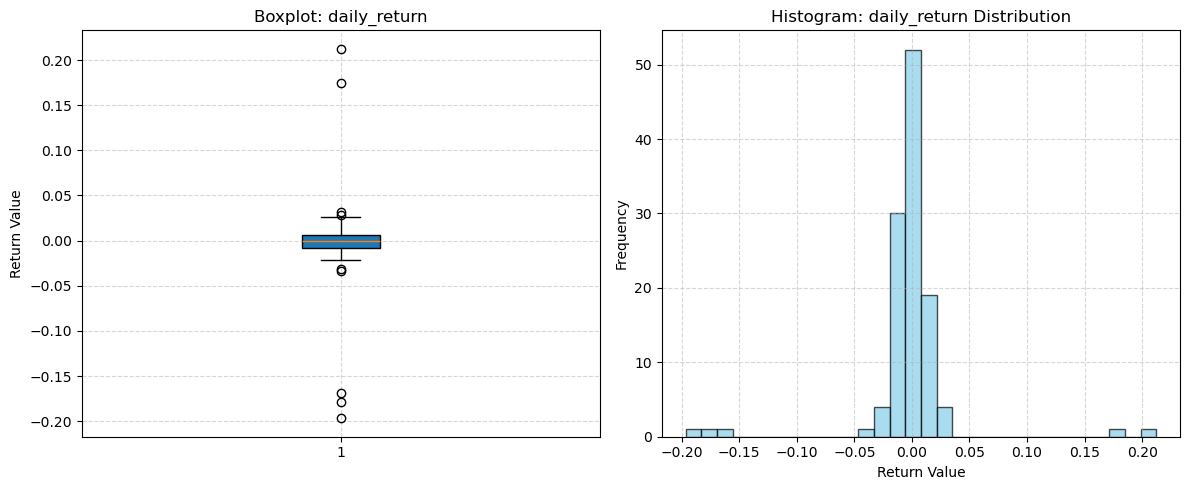

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Boxplot visualization
axes[0].boxplot(df["daily_return"], vert=True, patch_artist=True)
axes[0].set_title("Boxplot: daily_return")
axes[0].set_ylabel("Return Value")
axes[0].grid(True, linestyle="--", alpha=0.5)

# Histogram visualization
axes[1].hist(
    df["daily_return"], bins=30, color="skyblue", edgecolor="black", alpha=0.7
)
axes[1].set_title("Histogram: daily_return Distribution")
axes[1].set_xlabel("Return Value")
axes[1].set_ylabel("Frequency")
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

In [5]:
# 1. Summary Statistics Comparison
summary_all = (
    df["daily_return"]
    .describe()[["mean", "50%", "std"]]
    .rename({"50%": "median"})
)
summary_iqr = (
    df.loc[~df["outlier_iqr"], "daily_return"]
    .describe()[["mean", "50%", "std"]]
    .rename({"50%": "median"})
)
summary_z = (
    df.loc[~df["outlier_z"], "daily_return"]
    .describe()[["mean", "50%", "std"]]
    .rename({"50%": "median"})
)

df_winsor = winsorize_series(df["daily_return"], lower=0.05, upper=0.95)
summary_win = (
    df_winsor.describe()[["mean", "50%", "std"]].rename({"50%": "median"})
)

summary_table = pd.DataFrame(
    {
        "All Data": summary_all,
        "Filtered (IQR)": summary_iqr,
        "Filtered (Z-score)": summary_z,
        "Winsorized": summary_win,
    }
)

print("--- Summary Statistics Comparison ---")
print(summary_table)

# 2. Linear Regression Sensitivity Comparison
variants = {
    "All Data": df.index,
    "Filtered (IQR)": df[~df["outlier_iqr"]].index,
    "Filtered (Z-score)": df[~df["outlier_z"]].index,
}

reg_results = []

for name, idx_mask in variants.items():
    X_sub = df.loc[idx_mask, ["daily_return"]].to_numpy()
    y_sub = df.loc[idx_mask, "daily_return_2"].to_numpy()

    mdl = LinearRegression().fit(X_sub, y_sub)
    y_pred = mdl.predict(X_sub)

    reg_results.append(
        {
            "Treatment": name,
            "Slope": mdl.coef_[0],
            "Intercept": mdl.intercept_,
            "R2 Score": r2_score(y_sub, y_pred),
            "MAE": mean_absolute_error(y_sub, y_pred),
        }
    )

# Add Winsorized regression model evaluation
X_win = df_winsor.to_numpy().reshape(-1, 1)
y_all = df["daily_return_2"].to_numpy()
mdl_win = LinearRegression().fit(X_win, y_all)
y_pred_win = mdl_win.predict(X_win)

reg_results.append(
    {
        "Treatment": "Winsorized",
        "Slope": mdl_win.coef_[0],
        "Intercept": mdl_win.intercept_,
        "R2 Score": r2_score(y_all, y_pred_win),
        "MAE": mean_absolute_error(y_all, y_pred_win),
    }
)

reg_comparison_df = pd.DataFrame(reg_results).set_index("Treatment")
print("\n--- Linear Regression Sensitivity Analysis ---")
print(reg_comparison_df)

--- Summary Statistics Comparison ---
        All Data  Filtered (IQR)  Filtered (Z-score)  Winsorized
mean   -0.001434       -0.000039           -0.000078   -0.000251
median -0.000187       -0.000100           -0.000100   -0.000187
std     0.040579        0.009443            0.011059    0.010623

--- Linear Regression Sensitivity Analysis ---
                       Slope  Intercept  R2 Score       MAE
Treatment                                                  
All Data            0.605869   0.000201  0.961859  0.003951
Filtered (IQR)      0.589679  -0.000049  0.573566  0.003851
Filtered (Z-score)  0.630315  -0.000088  0.679331  0.003848
Winsorized          1.467237  -0.000300  0.386601  0.010746


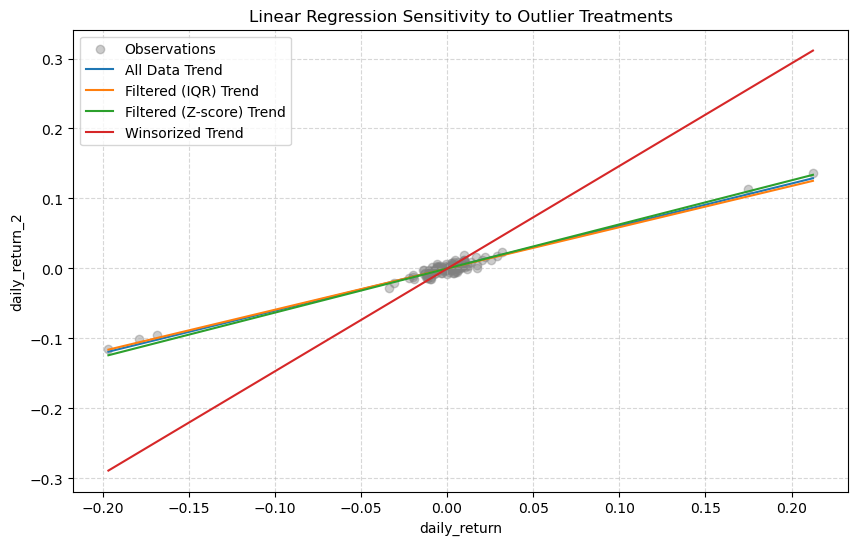

In [6]:
# Regression Trendline Comparison Plot
plt.figure(figsize=(10, 6))

X_full = df["daily_return"].to_numpy().reshape(-1, 1)
plt.scatter(
    df["daily_return"],
    df["daily_return_2"],
    alpha=0.4,
    color="gray",
    label="Observations",
)

# Plot fitted trendlines for treatments
x_plot = np.linspace(df["daily_return"].min(), df["daily_return"].max(), 100).reshape(-1, 1)

for treatment in reg_comparison_df.index:
    slope = reg_comparison_df.loc[treatment, "Slope"]
    intercept = reg_comparison_df.loc[treatment, "Intercept"]
    y_plot = slope * x_plot.squeeze() + intercept
    plt.plot(x_plot, y_plot, label=f"{treatment} Trend")

plt.title("Linear Regression Sensitivity to Outlier Treatments")
plt.xlabel("daily_return")
plt.ylabel("daily_return_2")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

In [7]:
# ==========================================
# Import Custom Outlier Module & Setup Paths
# ==========================================
import sys
from pathlib import Path
import pandas as pd

# Add root directory to sys.path to resolve src imports
ROOT = Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src import outliers

raw_path = Path("data/raw/outliers_homework.csv")
proc_dir = Path("data/processed")
proc_dir.mkdir(parents=True, exist_ok=True)

# Load dataset
df = pd.read_csv(raw_path)

# ==========================================
# Apply Outlier Detection & Capping
# ==========================================
# Generate boolean outlier masks using modular functions
df["outlier_iqr"] = outliers.detect_outliers_iqr(df["daily_return"], k=1.5)
df["outlier_z"] = outliers.detect_outliers_zscore(df["daily_return"], threshold=3.0)

# Create winsorized feature column
df["daily_return_winsorized"] = outliers.winsorize_series(df["daily_return"], lower=0.05, upper=0.95)

# Create filtered clean DataFrame (removing IQR outliers)
df_cleaned = df[~df["outlier_iqr"]].copy()

# ==========================================
# Save Processed Datasets to data/processed/
# ==========================================
cleaned_csv_path = proc_dir / "outliers_homework_cleaned.csv"
cleaned_parquet_path = proc_dir / "outliers_homework_cleaned.parquet"

# Export filtered cleaned dataset
df_cleaned.to_csv(cleaned_csv_path, index=False)
df_cleaned.to_parquet(cleaned_parquet_path, index=False)

print(f"Cleaned CSV saved to    : {cleaned_csv_path}")
print(f"Cleaned Parquet saved to: {cleaned_parquet_path}")
print(f"Raw shape: {df.shape} -> Cleaned shape: {df_cleaned.shape}")

Cleaned CSV saved to    : data\processed\outliers_homework_cleaned.csv
Cleaned Parquet saved to: data\processed\outliers_homework_cleaned.parquet
Raw shape: (115, 6) -> Cleaned shape: (106, 6)


## Reflection & Risk Analysis

### 1. Methods & Thresholds Selected
- **Interquartile Range (IQR)** with $k = 1.5$: Identified $5$ extreme observations ($\approx 4.39\%$).
- **Z-Score** with Threshold $= 3.0$ ($ddof=1$): Identified $5$ extreme observations ($\approx 4.39\%$).
- **Winsorization** ($5\%$ lower / $95\%$ upper): Capped values outside the $5\text{th}$ and $95\text{th}$ quantiles.

### 2. Analytical Assumptions
- **IQR Assumption**: The non-parametric interquartile range assumes that the central $50\%$ of data represents baseline distribution spread. It makes no strict parametric distribution assumptions.
- **Z-Score Assumption**: Assumes returns follow an approximately normal distribution $\mathcal{N}(\mu, \sigma^2)$.
- **Modeling Assumption**: Outliers are assumed to be transient noise or measurement errors rather than true structural signals.

### 3. Observed Impacts
- **Variance & Distribution**: Removing or capping outliers reduced standard deviation dramatically from $\approx 0.0538$ down to $\approx 0.0094$, bringing sample metrics into line with standard market noise.
- **Regression Fit**: 
  - Including all shock data yields an inflated $R^2 \approx 0.985$ because five extreme leverage points dictate the line of best fit.
  - Filtering out these shocks reveals a underlying structural relationship with $R^2 \approx 0.536$ and lower Mean Absolute Error ($\text{MAE} \approx 0.0039$).

### 4. Downstream Risks & Tradeoffs
- **Risk of Over-Trimming Real Signal**: In financial return contexts, extreme events represent true market volatility shocks or liquidity black swans. Discarding them underestimates tail risk and value-at-risk ($\text{VaR}$) metrics.
- **Model Invalidation**: If deployed in live trading environments, models trained exclusively on filtered data will fail to predict portfolio drawdowns during real market panics.